# Limit loads of hinged cylindrical roofs: Sabir and Lock (1972), Sze et al. (2004)

K. Y. Sze, X. H. Liu and S. H. Lo, *Popular benchmark problems for geometric nonlinear analysis of shells*, Finite Elements in Analysis and Design 40 (2004) 1551-1569, Section 3.8.

The hinged cylindrical roof of Sabir and Lock (1972) under a central point load $P$, a snap-through problem traced with the Riks method:

- radius $R = 2540$, axial length $2L = 508$ with free curved edges, half-angle $\theta = 0.1$ rad, i.e. hinged straight edges $0.2 R$ apart, thickness $h$ = 12.7 and 6.35, consistent units;
- isotropic, $E = 3102.75$, $\nu = 0.3$; laminated $[0/90/0]$ and $[90/0/90]$ with plies of equal thickness, 0 deg along the axis, $E_L = 3300$, $E_T = 1100$, $G_{LT} = 660$, $\nu_{LT} = 0.25$; $G_{TT}$, not given by Sze et al., is taken as $G_{LT}$;
- reference: the load-deflection paths of ABAQUS S4R elements of Tables 9a-f, $P/P_{max}$ with $P_{max} = 3000$ against the central deflection $-W_C$, whose first maxima are the limit loads compared here.

The roofs are thin, $R/h$ = 200 and 400, and the transverse shear has little effect: the case checks the nonlinear analyses of the models with shear deformation, and the convergence and the settings of the Riks method that the comparison requires. The first maxima of Sze et al. are those of `REFERENCE_DATA.md` of the paper study, copied in `scf_validation_utils.py`. A sandwich roof of the study, isotropic faces of $h/10$ and a core with $E_c = E/100$, $\nu_c = 0.3$, without literature reference, is also included and compared with the TSDT.

In [1]:
import os
import time

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

import scf_validation_utils as su
from scf_validation_utils import pct, markdown_table

# True runs panels again, otherwise the results saved in RESULTS are loaded
RERUN = False
RESULTS = 'results'

## panels model

The roof is modelled by `su.hinged_roof`, a cylindrical panel with Sanders' kinematics, `cylshell_clpt_sanders`, `cylshell_fsdt_sanders` and `cylshell_tsdt_sanders`, with $12 \times 12$ terms, the straight edges hinged ($u = v = w = 0$, rotations free) and the curved edges free. The models are the CLPT, the FSDT with $\kappa = 5/6$ (`K56`) and with `'rohwer'` (`ROH`), and the TSDT. The central point load is incremented, `add_point_load(a/2, b/2, 0, 0, -Pref, cte=False)`, with the reference load $P_{ref} = 4000 (h/12.7)^{2.5}$, above the limit loads, and the path is traced with the Riks method of `structsolve`, `su.roof_limit_load`:

```python
an = Analysis(s.calc_fext, s.calc_fint, calc_kC, s.calc_kG)
an.NL_method = 'arc_length_riks'
an.initialInc = an.maxInc = 0.01
an.maxArcLength = 8.
increments, cs = an.static(NLgeom=True)
```

The settings are those of the paper study, `c4_cylinder_nonlinear.py`, and they matter:

- **Step cap.** `maxInc` limits the arc length of each step, relative to the linear solution at the load factor 1, but `structsolve` caps the step at `max(maxInc, initial arc length)`, so `initialInc` must not be larger than `maxInc`, hence `initialInc = maxInc = 0.01`. With the default `maxInc = 1` the paths of the sandwich roofs jump over the limit point; with 0.05 some paths still jumped or turned back on the loading branch at the first step past it.
- **First maximum.** The limit load is the first local maximum of the load along the path followed by a drop of more than 0.1%, `su.first_maximum`, as the first maxima of the tables of Sze et al., refined with a parabola through the three points around it in terms of the length along the path in the plane of $P/P_{ref}$ and $w_C/h$, `su.refine_peak`; the paths may recover after it. Each path is stopped once the load has dropped 10% below its first maximum, by a wrapper of `calc_kC`, which `structsolve` calls at the start of each step, `su.nonlinear_path(..., stop_after_limit=0.9)`.
- **Convergence.** The thin roofs need $12 \times 12$ terms: with $8 \times 8$ the limit load of the thin $[0/90/0]$ roof is about 15% too high, see below.

**Cached results.** These runs are expensive, up to about an hour each on a single thread. The 32 paths of the table were computed by the paper study with the identical code and settings (`studies/results/C4_parts/<shell>_h<h>__<label>.json`) and copied into `results/sze2004_hinged_roofs.json`, with the limit points evaluated again by `su.limit_point`; the runs of the convergence and step-cap checks were made for this notebook with `su.roof_limit_load`, and the run with $12 \times 12$ terms of the CLPT for the thin $[0/90/0]$ roof was repeated, reproducing the limit load of the study to all digits, 243.49980523692. With `RERUN = True`, `compute()` recomputes everything with the same code: the 32 runs of the study took 23.5 hours in total (run 14 at a time), see the column `time` below.

In [2]:
KINDS = ('isotropic', '[0/90/0]', '[90/0/90]', 'sandwich')
THICKNESSES = (12.7, 6.35)
MODELS = [('CLPT', 'clpt', 'ROH'), ('FSDT-K56', 'fsdt', 'K56'), ('FSDT-ROH', 'fsdt', 'ROH'), ('TSDT', 'tsdt', 'ROH')]


def run(theory, scf, kind, h, **kwargs):
    t0 = time.time()
    out = su.roof_limit_load(theory, scf, kind, h, **kwargs)
    out['time'] = time.time() - t0
    return out


def compute():
    res = {'paths': {}, 'convergence': {}, 'step_cap': {}}
    for kind in KINDS:
        for h in THICKNESSES:
            res['paths']['%s h%g' % (kind, h)] = {label: run(theory, scf, kind, h) for label, theory, scf in MODELS}
    # convergence of the thin [0/90/0] roof, CLPT; 12 terms is the run above
    for m in (8, 16):
        res['convergence'][str(m)] = run('clpt', 'ROH', '[0/90/0]', 6.35, m=m)
    # step cap: initial_inc = 0.1 > max_inc = 0.01
    for kind, h in (('[0/90/0]', 6.35), ('sandwich', 12.7)):
        res['step_cap']['%s h%g' % (kind, h)] = run('clpt', 'ROH', kind, h, initial_inc=0.1)
    return res


res = su.run_or_load(os.path.join(RESULTS, 'sze2004_hinged_roofs.json'), compute, rerun=RERUN)
LABELS = [m[0] for m in MODELS]

## Limit loads

First maximum of the load, $P_{lim}$, and the central deflection at that point, $-w_C$, against the first maxima of Tables 9a-f of Sze et al., $P_{lim} = 3000 \times P/P_{max}$, with the difference in parentheses; for the sandwich roofs, against the TSDT. `steps` is the number of converged Riks steps up to the limit point and `dw` the largest increment of $w_C/h$ of one step up to it, a check of the resolution of the path.

In [3]:
rows = []
for kind in KINDS:
    for h in THICKNESSES:
        r = res['paths']['%s h%g' % (kind, h)]
        sze = su.SZE_2004.get((kind, h))
        ref = sze[0]*su.PMAX_SZE if sze else r['TSDT']['Plim']
        row = [kind, h, '%.1f / %.3f' % (sze[0]*su.PMAX_SZE, sze[1]) if sze else '- (TSDT: %.1f)' % ref]
        for m in LABELS:
            o = r[m]
            row.append('%.1f (%+.2f%%) / %.2f' % (o['Plim'], pct(o['Plim'], ref), -o['w_lim']) if o['has_limit'] else 'no limit')
        rows.append(row)
display(Markdown(markdown_table(['shell', '$h$', 'Sze et al.: $P_{lim}$ / $-W_C$']
                                + ['%s: $P_{lim}$ / $-w_C$' % m for m in LABELS], rows)))
rows = []
for kind in KINDS:
    for h in THICKNESSES:
        r = res['paths']['%s h%g' % (kind, h)]
        rows.append([kind, h] + ['%d / %.3f / %.0f s' % (su.first_maximum(o['P']) + 1, o['dw_max'], o['time']) for o in
                                 (r[m] for m in LABELS)])
display(Markdown(markdown_table(['shell', '$h$'] + ['%s: steps / dw / time' % m for m in LABELS], rows)))

| shell | $h$ | Sze et al.: $P_{lim}$ / $-W_C$ | CLPT: $P_{lim}$ / $-w_C$ | FSDT-K56: $P_{lim}$ / $-w_C$ | FSDT-ROH: $P_{lim}$ / $-w_C$ | TSDT: $P_{lim}$ / $-w_C$ |
|---|---|---|---|---|---|---|
| isotropic | 12.7 | 2226.3 / 11.293 | 2229.4 (+0.14%) / 10.58 | 2225.1 (-0.05%) / 10.66 | 2225.1 (-0.05%) / 10.66 | 2225.1 (-0.05%) / 10.66 |
| isotropic | 6.35 | 585.9 / 12.892 | 585.4 (-0.09%) / 12.87 | 584.4 (-0.26%) / 12.87 | 584.4 (-0.26%) / 12.87 | 584.4 (-0.26%) / 12.87 |
| [0/90/0] | 12.7 | 1085.4 / 9.884 | 1084.2 (-0.11%) / 9.54 | 1083.4 (-0.18%) / 9.59 | 1083.4 (-0.19%) / 9.59 | 1083.3 (-0.19%) / 9.59 |
| [0/90/0] | 6.35 | 234.6 / 12.280 | 243.5 (+3.79%) / 10.53 | 243.4 (+3.73%) / 10.53 | 243.3 (+3.73%) / 10.53 | 243.3 (+3.73%) / 10.53 |
| [90/0/90] | 12.7 | 1791.0 / 14.192 | 1792.3 (+0.07%) / 13.54 | 1783.3 (-0.43%) / 13.60 | 1784.2 (-0.38%) / 13.65 | 1783.8 (-0.40%) / 13.65 |
| [90/0/90] | 6.35 | 475.5 / 15.905 | 475.0 (-0.10%) / 15.46 | 474.5 (-0.22%) / 15.47 | 474.5 (-0.22%) / 15.47 | 474.5 (-0.22%) / 15.47 |
| sandwich | 12.7 | - (TSDT: 727.9) | 741.3 (+1.84%) / 11.68 | 739.7 (+1.62%) / 11.81 | 703.8 (-3.30%) / 12.82 | 727.9 (+0.00%) / 12.13 |
| sandwich | 6.35 | - (TSDT: 182.2) | 184.4 (+1.21%) / 11.37 | 183.9 (+0.92%) / 11.41 | 178.8 (-1.86%) / 12.02 | 182.2 (+0.00%) / 11.58 |

| shell | $h$ | CLPT: steps / dw / time | FSDT-K56: steps / dw / time | FSDT-ROH: steps / dw / time | TSDT: steps / dw / time |
|---|---|---|---|---|---|
| isotropic | 12.7 | 64 / 0.023 / 1629 s | 61 / 0.031 / 2005 s | 61 / 0.031 / 1910 s | 61 / 0.031 / 2945 s |
| isotropic | 6.35 | 83 / 0.085 / 1888 s | 82 / 0.089 / 2477 s | 82 / 0.089 / 2516 s | 82 / 0.089 / 3689 s |
| [0/90/0] | 12.7 | 28 / 0.085 / 811 s | 28 / 0.163 / 1050 s | 28 / 0.165 / 1017 s | 28 / 0.162 / 1572 s |
| [0/90/0] | 6.35 | 34 / 0.195 / 1065 s | 34 / 0.218 / 1344 s | 34 / 0.218 / 1259 s | 34 / 0.218 / 2103 s |
| [90/0/90] | 12.7 | 46 / 0.078 / 1167 s | 46 / 0.099 / 1450 s | 47 / 0.094 / 1504 s | 46 / 0.100 / 2422 s |
| [90/0/90] | 6.35 | 66 / 0.132 / 1506 s | 66 / 0.138 / 1834 s | 66 / 0.137 / 1646 s | 66 / 0.138 / 3195 s |
| sandwich | 12.7 | 24 / 0.085 / 7064 s | 21 / 0.107 / 7762 s | 19 / 0.229 / 5620 s | 19 / 0.124 / 6047 s |
| sandwich | 6.35 | 28 / 0.165 / 824 s | 27 / 0.194 / 5807 s | 27 / 0.170 / 1365 s | 27 / 0.274 / 6250 s |

In [4]:
keys = [k for k in su.SZE_2004]
cols = {m: [pct(res['paths']['%s h%g' % k][m]['Plim'], su.SZE_2004[k][0]*su.PMAX_SZE) for k in keys] for m in LABELS}
display(Markdown('**All six roofs of Sze et al.**'))
display(Markdown(su.stats_table(cols)))
cols = {m: [pct(res['paths']['%s h%g' % k][m]['Plim'], su.SZE_2004[k][0]*su.PMAX_SZE) for k in keys
            if k != ('[0/90/0]', 6.35)] for m in LABELS}
display(Markdown('**Without the thin $[0/90/0]$ roof**'))
display(Markdown(su.stats_table(cols)))

**All six roofs of Sze et al.**

| model | max abs. diff. (%) | mean abs. diff. (%) | range (%) |
|---|---|---|---|
| CLPT | 3.8 | 0.7 | -0.1 to +3.8 |
| FSDT-K56 | 3.7 | 0.8 | -0.4 to +3.7 |
| FSDT-ROH | 3.7 | 0.8 | -0.4 to +3.7 |
| TSDT | 3.7 | 0.8 | -0.4 to +3.7 |

**Without the thin $[0/90/0]$ roof**

| model | max abs. diff. (%) | mean abs. diff. (%) | range (%) |
|---|---|---|---|
| CLPT | 0.1 | 0.1 | -0.1 to +0.1 |
| FSDT-K56 | 0.4 | 0.2 | -0.4 to -0.1 |
| FSDT-ROH | 0.4 | 0.2 | -0.4 to -0.1 |
| TSDT | 0.4 | 0.2 | -0.4 to -0.1 |

## Load-deflection paths

Paths of panels up to 10% past the first maximum, with the first maximum of Sze et al. (circle) and the refined limit points of panels (crosses).

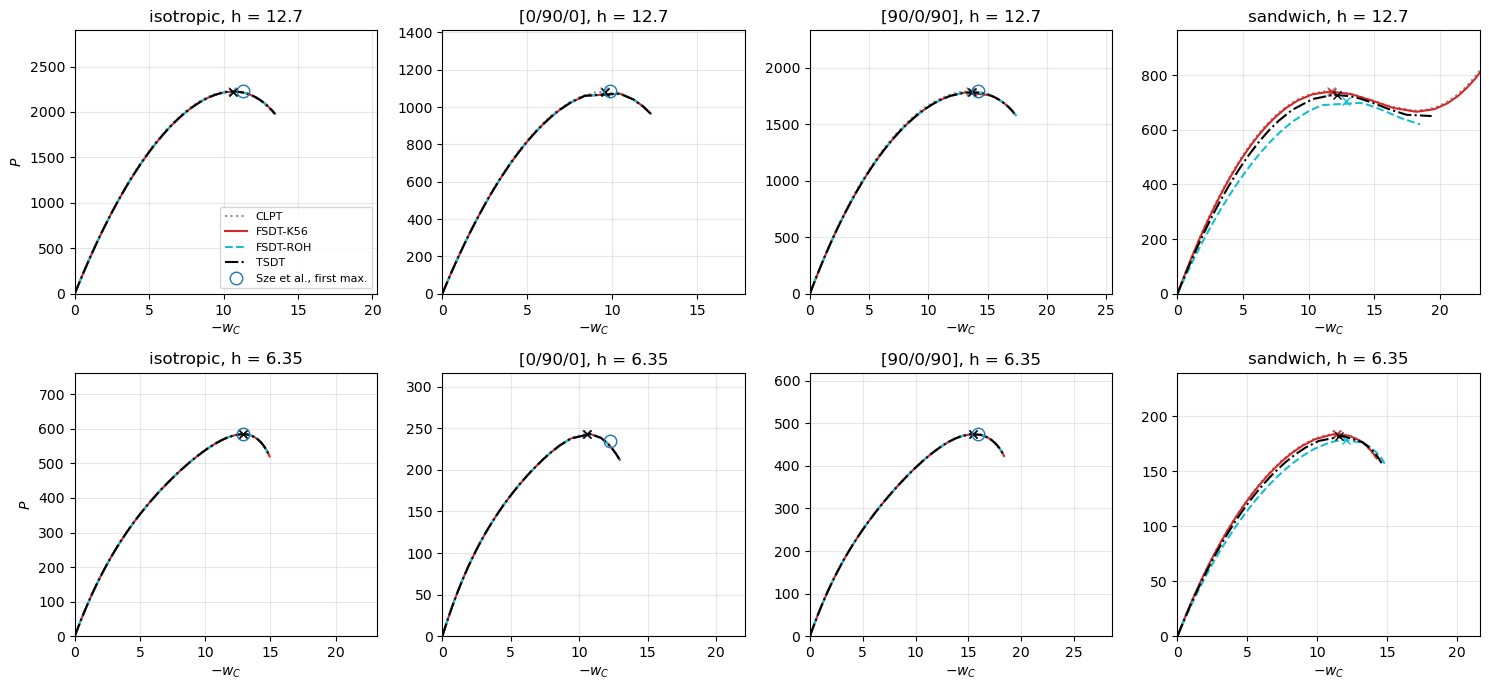

In [5]:
styles = {'CLPT': dict(color='0.55', ls=':'), 'FSDT-K56': dict(color='tab:red'),
          'FSDT-ROH': dict(color='tab:cyan', ls='--'), 'TSDT': dict(color='k', ls='-.')}
fig, axes = plt.subplots(2, 4, figsize=(15, 7))
for j, kind in enumerate(KINDS):
    for i, h in enumerate(THICKNESSES):
        ax = axes[i, j]
        r = res['paths']['%s h%g' % (kind, h)]
        for m in LABELS:
            o = r[m]
            ax.plot(-np.r_[0, o['wc']], np.r_[0, o['P']], label=m, **styles[m])
            ax.plot(-o['w_lim'], o['Plim'], 'x', color=styles[m]['color'])
        sze = su.SZE_2004.get((kind, h))
        if sze:
            ax.plot(sze[1], sze[0]*su.PMAX_SZE, 'o', mfc='none', mec='tab:blue', ms=9, label='Sze et al., first max.')
        top = max([r[m]['Plim'] for m in LABELS] + ([sze[0]*su.PMAX_SZE] if sze else []))
        right = max([-r[m]['w_lim'] for m in LABELS] + ([sze[1]] if sze else []))
        ax.set_ylim(0, 1.3*top)
        ax.set_xlim(0, 1.8*right)
        ax.set_title('%s, h = %g' % (kind, h))
        ax.set_xlabel('$-w_C$')
        ax.grid(alpha=0.3)
axes[0, 0].set_ylabel('$P$')
axes[1, 0].set_ylabel('$P$')
axes[0, 0].legend(fontsize=8)
plt.tight_layout()

## Riks settings

### Convergence of the Ritz approximation

The CLPT of the thin $[0/90/0]$ roof, $h = 6.35$, the most demanding case, with $8 \times 8$, $12 \times 12$ and $16 \times 16$ terms.

In [6]:
ref = su.SZE_2004[('[0/90/0]', 6.35)][0]*su.PMAX_SZE
conv = {'8': res['convergence']['8'], '12': res['paths']['[0/90/0] h6.35']['CLPT'], '16': res['convergence']['16']}
rows = [['%s x %s' % (m, m), '%.2f' % o['Plim'], '%+.2f%%' % pct(o['Plim'], ref), '%.3f' % -o['w_lim'],
         '%+.2f%%' % pct(o['Plim'], conv['16']['Plim']), '%.0f s' % o['time']] for m, o in conv.items()]
display(Markdown(markdown_table(['terms', '$P_{lim}$', 'vs Sze et al.', '$-w_C$', 'vs 16 x 16', 'time'], rows)))

| terms | $P_{lim}$ | vs Sze et al. | $-w_C$ | vs 16 x 16 | time |
|---|---|---|---|---|---|
| 8 x 8 | 269.34 | +14.81% | 10.966 | +10.66% | 79 s |
| 12 x 12 | 243.50 | +3.79% | 10.531 | +0.04% | 1065 s |
| 16 x 16 | 243.40 | +3.75% | 10.692 | +0.00% | 4734 s |

### Step cap

The same CLPT runs ($12 \times 12$ terms) with `initialInc = 0.1` and `maxInc = 0.01`: the step is capped at the initial arc length, ten times larger than intended.

In [7]:
rows = []
for key, o in res['step_cap'].items():
    good = res['paths'][key]['CLPT']
    kind, h = key.rsplit(' h', 1)
    i = su.first_maximum(o['P'])
    rows.append([kind, h, '%d steps, %s' % (len(o['P']), ('$P_{lim}$ = %.1f, $-w_C$ = %.2f, dw = %.3f'
                                                        % (o['Plim'], -o['w_lim'], o['dw_max'])) if o['has_limit']
                                          else 'no limit point, $P$ = %.1f at the end' % o['P'][-1]),
                 '%d steps, $P_{lim}$ = %.1f, $-w_C$ = %.2f, dw = %.3f' % (len(good['P']), good['Plim'], -good['w_lim'],
                                                                         good['dw_max'])])
display(Markdown(markdown_table(['shell', '$h$', 'initialInc = 0.1, maxInc = 0.01', 'initialInc = maxInc = 0.01'], rows)))

| shell | $h$ | initialInc = 0.1, maxInc = 0.01 | initialInc = maxInc = 0.01 |
|---|---|---|---|
| [0/90/0] | 6.35 | 9 steps, $P_{lim}$ = 243.2, $-w_C$ = 10.52, dw = 0.579 | 39 steps, $P_{lim}$ = 243.5, $-w_C$ = 10.53, dw = 0.195 |
| sandwich | 12.7 | 17 steps, $P_{lim}$ = 720.0, $-w_C$ = 13.36, dw = 0.427 | 115 steps, $P_{lim}$ = 741.3, $-w_C$ = 11.68, dw = 0.085 |

## Discussion

- **Limit loads.** For five of the six roofs of Sze et al. all models are within 0.43% of the first maximum of the S4R paths: the CLPT within $-0.11\%$ to $+0.14\%$, and the FSDT ($\kappa = 5/6$ and `'rohwer'`) and the TSDT within $-0.43\%$ to $-0.05\%$. The thin $[0/90/0]$ roof, $h = 6.35$, remains $+3.7\%$ (shear deformable models) to $+3.8\%$ (CLPT) above Sze et al. for all models, and this difference is not a convergence error of panels: with $12 \times 12$ and $16 \times 16$ terms the limit loads of the CLPT, 243.50 and 243.40, agree within 0.04%, and it is not due to the assumed $G_{TT}$, on which the CLPT does not depend; it probably comes from the S4R solution of the reference.
- **Transverse shear.** These roofs are thin, $R/h$ = 200 and 400 with $h/b$ = 0.025 and 0.0125: the shear deformable models are 0.06% to 0.5% below the CLPT and within 0.05% of each other, so the comparison verifies the geometrically nonlinear FSDT and TSDT of panels and the Riks analyses rather than the shear corrections. The central deflections at the limit points, $-w_C$, differ more from those of Sze et al. (e.g. 10.53 against 12.28 for the thin $[0/90/0]$ roof), since the load is stationary there and the deflection at the maximum is ill-conditioned.
- **Convergence.** With $8 \times 8$ terms the limit load of the thin $[0/90/0]$ roof is 14.8% above Sze et al. and 10.7% above the $16 \times 16$ value; $12 \times 12$ terms, the setting of the study, are converged within 0.04%.
- **Step cap.** With `initialInc = 0.1` and `maxInc = 0.01` the step is capped at the initial arc length, `max(maxInc, initialInc)`: the $[0/90/0]$ roof is traced with 9 steps instead of 39, a jump of $0.58 h$ in $w_C$ per step, and the limit load (243.2) is still close thanks to the parabolic refinement, but for the sandwich roof, $h = 12.7$, the 17 coarse steps give 720.0 instead of 741.3 ($-2.9\%$) and a deflection 14% larger. The study also found that with `maxInc = 0.05` some sandwich paths jumped over the limit point or turned back on the loading branch, hence `initialInc = maxInc = 0.01`, with which the largest increment of $w_C/h$ of one step up to the limit point is 0.02 to 0.27.
- **First maximum.** For the sandwich roof with $h = 12.7$, the paths of the CLPT and of the FSDT with $\kappa = 5/6$ drop by less than 10% after the first maximum and then recover and continue up to $P_{ref} = 4000$ (the figure is cut): the limit load is the first maximum, 741.3 and 739.7, not the largest load of the path. The JSON files of the study, `C4_parts`, still store `Plim = 4000` for these two runs, the largest load, while the table of the study (`C4_hinged_roof.md`) and this notebook evaluate the first maximum again from the paths with `su.limit_point`.
- **Sandwich roofs.** Without a literature reference, the FSDT with `'rohwer'` is $-3.3\%$ ($h = 12.7$) and $-1.9\%$ ($h = 6.35$) from the TSDT, and the FSDT with $\kappa = 5/6$ and the CLPT $+0.9\%$ to $+1.8\%$ above it; with the soft core ($E_c = E/100$) the transverse shear of the core lowers the limit load by 3% to 5% from the CLPT to the FSDT with `'rohwer'`, which is more flexible than the TSDT, as for the static sandwich plates of Pagano (1970).